# Tufa Labs ARC3 submission

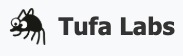

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [1]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

taaf.kaggle: TRUE_SUBMISSION=False


## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [2]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

0

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [3]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["thtennant/taaf-kaggle-source-share-fork", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

taaf.kaggle: source bundle = /kaggle/input/datasets/thtennant/taaf-kaggle-source-share-fork
taaf.kaggle: input paths = {"driessmit1/arc3-vllm-h100-wheelhouse-v3": "/kaggle/input/datasets/driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot": "/kaggle/input/datasets/driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot", "thtennant/taaf-kaggle-source-share-fork": "/kaggle/input/datasets/thtennant/taaf-kaggle-source-share-fork"}


## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [4]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

taaf.kaggle: wrote /usr/local/lib/python3.12/dist-packages/taaf_kaggle_sources.pth (4 source roots)
taaf.kaggle: setup command: "$PYTHON" - <<'PYSETUP'
import json
import os
import shutil
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

WHEELHOUSE_OWNER = 'driessmit1'
WHEELHOUSE_SLUG = 'arc3-vllm-h100-wheelhouse-v3'
MODEL_OWNER = 'driessmit1'
MODEL_SLUG = 'vrfai-qwen3-6-27b-fp8-hf-snapshot'
SERVED_MODEL_NAME = 'vrfai/Qwen3.6-27B-FP8'
VLLM_HOST = '127.0.0.1'
VLLM_PORT = 1234
VLLM_BASE_URL = f'http://{VLLM_HOST}:{VLLM_PORT}/v1'
VLLM_MAX_MODEL_LEN = 65536
ANALYZER_CONTEXT_WINDOW = 32768
VLLM_TENSOR_PARALLEL_SIZE = 1
WORKING_DIR = Path(os.environ['TAAF_KAGGLE_WORKING_DIR'])
SITE_PACKAGES = WORKING_DIR / 'vllm-site-packages'
VLLM_SERVER_LOG = WORKING_DIR / 'vllm-openai-server.log'
VLLM_SERVER_PID = WORKING_DIR / 'vllm-openai-server.pid'
INSTALL_STAMP = SITE_PACKAGES / f'.{WHEELHOUSE_SLUG}'
STAMP_TEXT = 'vllm==0.19.0 torch==2.10.0 flashinfer==0.6.6\n'


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [5]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [6]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
# Example:
# bm.label = f"{bm.label}-debug"

# Composite graft install (v12): the single cell-12 entry point shipped in our
# forked source bundle (thtennant/taaf-kaggle-source-share-fork, src/taaf-grafts),
# importable here because the source-import cell above put every bundled repo on
# sys.path. install(bm, flags) wires the EfficiencyToolAgent analyzer (budget-aware
# per-turn note + net-zero waste detection, report-only) plus the RetryGuard
# analyzer chain layer (a proven pass-through rider) plus shortcircuit (no-op
# overshoot trimmer), printing the machine-parseable
# 'TAAF_GRAFTS FEATURES={...} API_VERSION=1' banner the commit-log gate reads.
# The run cell below reassigns bm.games (offline dup-game gate included) but never
# touches bm.solver, so swapping the solver instance here is safe: Benchmark.run
# deepcopies whatever solver is present at run time.
# install() is itself blanket-guarded (restores the original bm.solver on ANY
# error); the extra try/except-pass here is belt-and-suspenders so even an import
# failure of composite leaves bm.solver untouched (stock HarnessSolver).
try:
    from taaf_grafts.composite import install

    install(bm, flags={"efficiency": True, "retry_guard": True, "shortcircuit": True,"recovery": True})
except Exception as exc:  # noqa: BLE001 — any graft failure must fall back to stock
    print(f"[taaf_grafts] cell-12 graft failed, running stock: {type(exc).__name__}: {exc}")


TAAF_GRAFTS FEATURES={"efficiency":true,"recovery":true,"retry_guard":true,"shortcircuit":true} API_VERSION=1
[recovery] armed


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [7]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

# Safety pack + dup-game commit gate: keep interactive commit runs short AND make
# the transfer family store fire. Provably inert in a real rerun (guarded on
# TRUE_SUBMISSION); it must live in this cell, after the branches above, because
# both branches reassign bm.games (cell 12 runs first). The duplicate is the SAME
# env as games[0] added via GameAPI.external_game_id (game_api.py:155) — Benchmark's
# unique-game_id check (benchmark.py:160) is satisfied because the dup carries a
# distinct game_id, while the shared arcade_spec keeps it in games[0]'s fingerprint
# family: games[0] scouts and publishes, the dup replays. Any construction fault
# falls back to the plain [:4] truncation.
if not TRUE_SUBMISSION:
    try:
        import taaf.game_api

        first = bm.games[0]
        bm.games = bm.games[:3] + [
            taaf.game_api.GameAPI(
                env_name=first.env_name,
                arcade_spec=first.arcade_spec,
                external_game_id=f"{first.env_name}-dup",
            )
        ]
    except Exception as exc:  # noqa: BLE001 — any dup fault falls back to plain truncation
        print(f"[taaf_grafts] dup-game gate failed, using [:4]: {type(exc).__name__}: {exc}")
        bm.games = bm.games[:4]

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))
else:
    # Safety pack: a real rerun used to run with soft_end=None (no global soft
    # deadline; the wall budget was emergent). Cap at run start + 11h20m so the
    # solver drains and the shared scorecard closes before Kaggle's hard kill.
    soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(hours=11, minutes=20)

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

benchmark.label : duck-harness-kaggle
benchmark.solver: HarnessSolver(label='duck-harness', runtime_environment=None, job_dir=None, soft_end_time=None, minimal_diagnostics=False, model='local', analyzer_timeout=900.0, max_actions_per_game=None, max_runtime_s_per_game=7920.0, concurrency=28, save_request_logs=False, start_local_server=False, local_server_config='', local_server_api_key_file='', local_server_repo_dir='/Users/jeroencottaar/code/ARC3-Inference', local_server_port=None, local_server_tensor_parallel_size=None, local_server_count=1, cancel_drain_timeout_s=120.0)
benchmark.passes: 1
benchmark.games : 25
git status:
  ARC3-Inference                   aa69123     DIRTY  add-kaggle-share-flag     Add flag to use shareable notebook
  tufa-arc-agi-framework           fe9f7c4     clean  submission-share-mode-bugfix  Fix dataset mapping, spell Isaiah's name properly
  re-arc-3                         57e46d619d  pinned  master                    (non-editable)
benchmark: regenerated 

analyzer request failed at action 22: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=900.0)


benchmark: regenerated diagnostics in /kaggle/working in 0.54s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     4
passes:    1
runs:      4 (won: 0)
started:   2026-07-15 02:15:06
ended:     in progress
mean score:    0.00
median score:  0.00
total actions: 496
total tokens:  205900
generated tokens/sec: 85.69 (job wallclock)
total wallclock: 8843.5s

per-game (mean across passes):
  m0r0-492f87ba: score=0.00, levels=0.0/6, actions=82, tokens=53287
  sk48-d8078629: score=0.00, levels=0.0/8, actions=200, tokens=55395
  sk48-d8078629-dup: score=0.00, levels=0.0/8, actions=171, tokens=59298
  tn36-ef4dde99: score=0.00, levels=0.0/7, actions=43, tokens=37920



analyzer request failed at action 83: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=900.0)


benchmark: regenerated diagnostics in /kaggle/working in 0.85s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     4
passes:    1
runs:      4 (won: 0)
started:   2026-07-15 02:15:06
ended:     in progress
mean score:    0.00
median score:  0.00
total actions: 552
total tokens:  261773
generated tokens/sec: 87.15 (job wallclock)
total wallclock: 10947.3s

per-game (mean across passes):
  m0r0-492f87ba: score=0.00, levels=0.0/6, actions=82, tokens=53287
  sk48-d8078629: score=0.00, levels=0.0/8, actions=215, tokens=77515
  sk48-d8078629-dup: score=0.00, levels=0.0/8, actions=192, tokens=75818
  tn36-ef4dde99: score=0.00, levels=0.0/7, actions=63, tokens=55153

benchmark: regenerated diagnostics in /kaggle/working in 0.57s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     4
passes:    1
runs:      4 (won: 0)
started:   2026-07-15 02:15:06
ended:     in progress
mean score:    0.00
median score:  0.00
total actions: 654
total tokens:  318913
generated tokens/

...

[finished] sk48-d8078629 state=gave_up level=0/8 score=0.00 actions=266 tokens=157578 per-level=266/61,0/177,0/101,0/103,0/230,0/181,0/125,0/92 note="tokens=159730"
[finished] tn36-ef4dde99 state=gave_up level=1/7 score=0.13 actions=244 tokens=160297 per-level=171/32,73/72,0/26,0/40,0/30,0/55,0/62 note="tokens=160297"


analyzer request failed at action 536: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=2.2020270969997)


[finished] m0r0-492f87ba state=gave_up level=0/6 score=0.00 actions=535 tokens=179761 per-level=535/30,0/111,0/203,0/26,0/500,0/237 note="tokens=179761"


analyzer request failed at action 354: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=35.2061831459996)


[finished] sk48-d8078629-dup state=gave_up level=0/8 score=0.00 actions=353 tokens=205650 per-level=353/61,0/177,0/101,0/103,0/230,0/181,0/125,0/92 note="tokens=206205"
benchmark: regenerated diagnostics in /kaggle/working in 1.64s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     4
passes:    1
runs:      4 (won: 0)
started:   2026-07-15 02:15:06
ended:     2026-07-15 04:27:26
duration:  2h 12m 20s
mean score:    0.03
median score:  0.00
total actions: 1398
total tokens:  703286
generated tokens/sec: 88.57 (job wallclock)
total wallclock: 31701.4s

per-game (mean across passes):
  m0r0-492f87ba: score=0.00, levels=0.0/6, actions=535, tokens=179761
  sk48-d8078629: score=0.00, levels=0.0/8, actions=266, tokens=157578
  sk48-d8078629-dup: score=0.00, levels=0.0/8, actions=353, tokens=205650
  tn36-ef4dde99: score=0.13, levels=1.0/7, actions=244, tokens=160297

diagnostics: /kaggle/working/diagnostics.html
taaf.kaggle: teardown command: "$PYTHON" - <<'PYTEARDOWN'
import o

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")



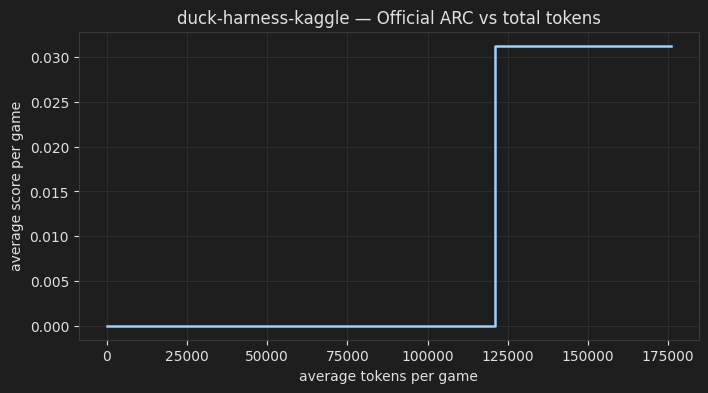
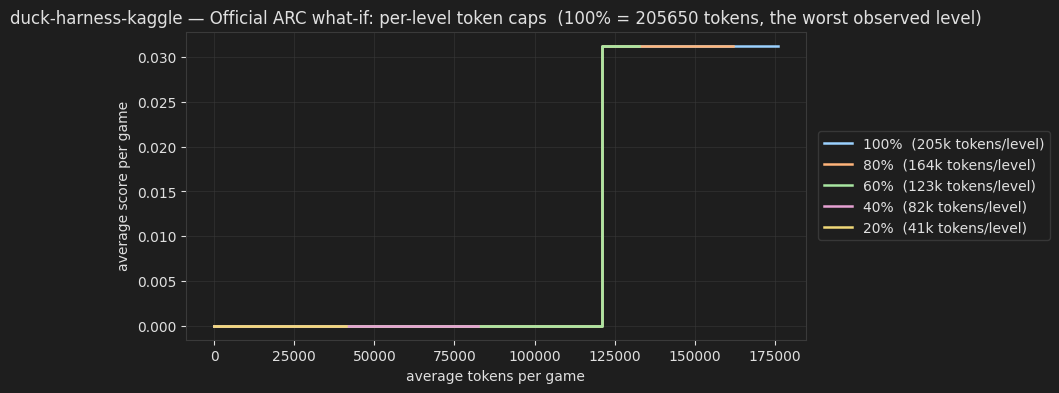
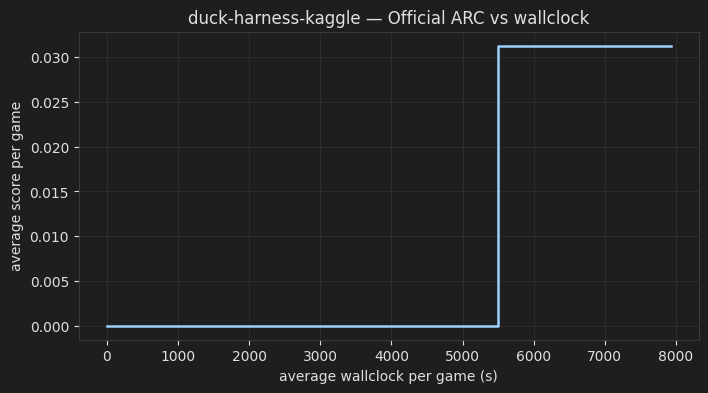
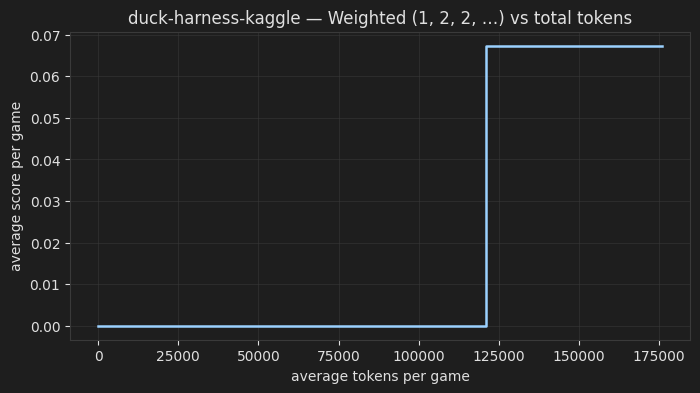
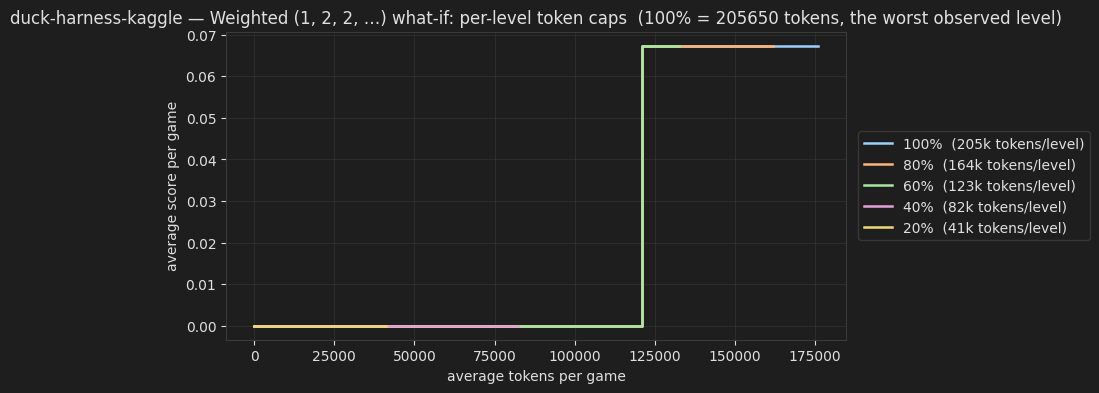
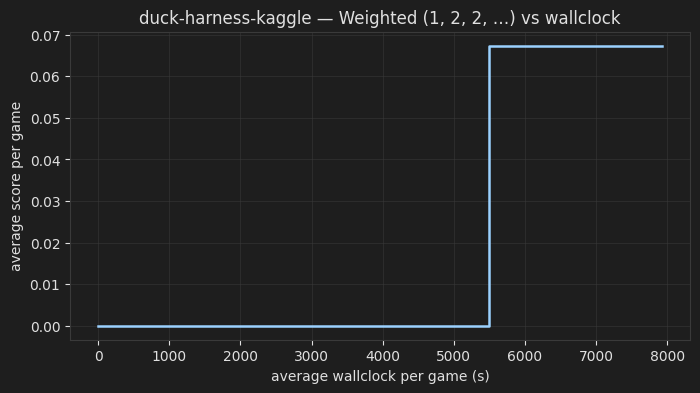
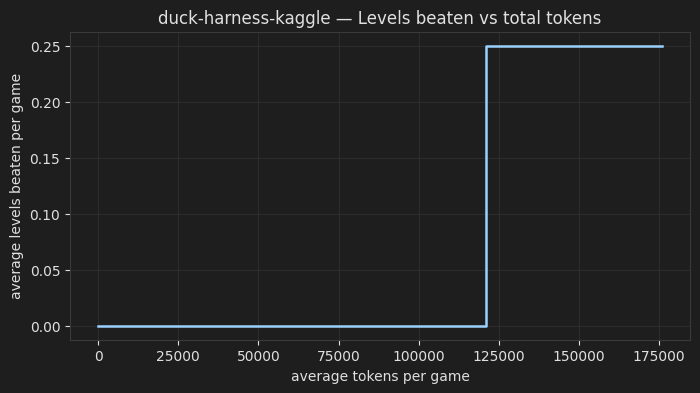
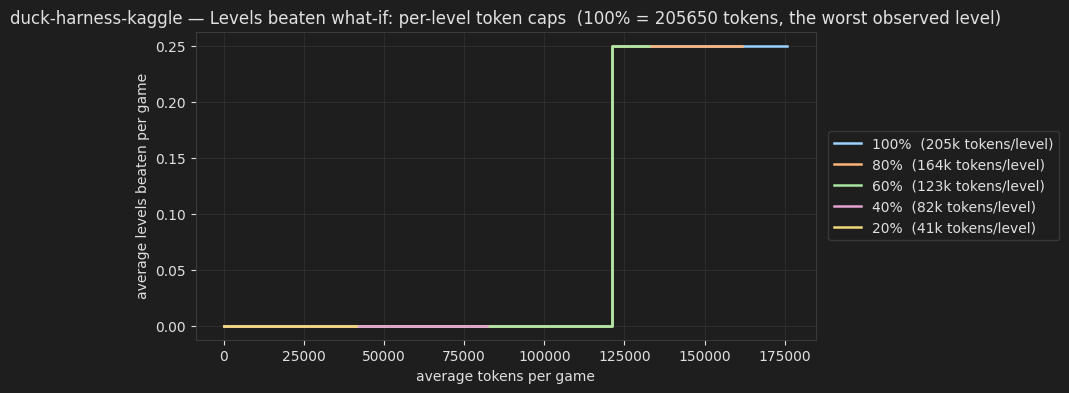
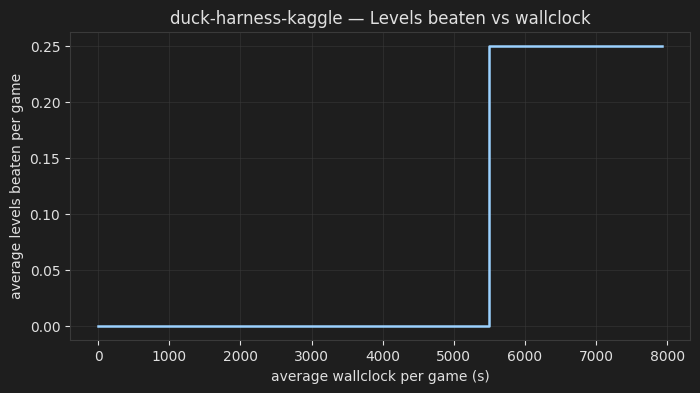
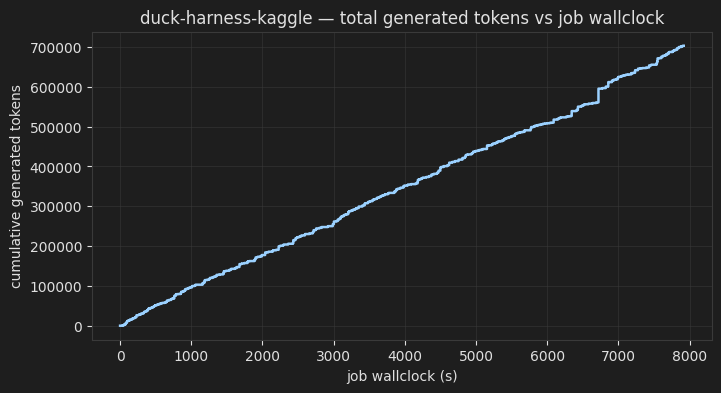
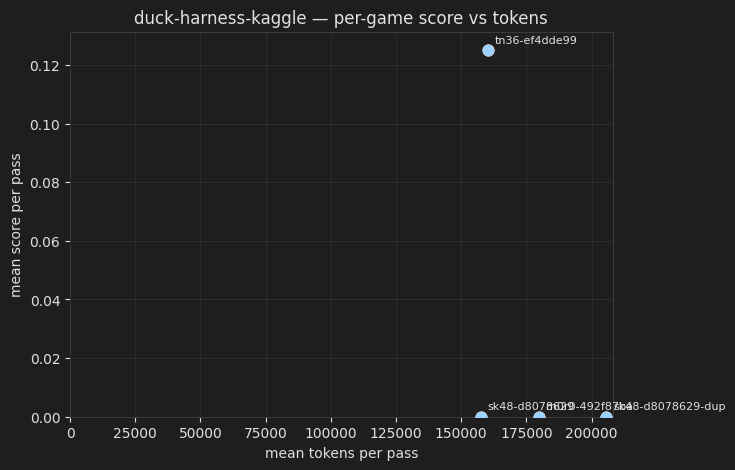
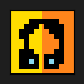
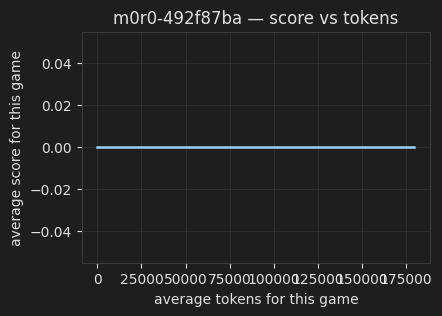
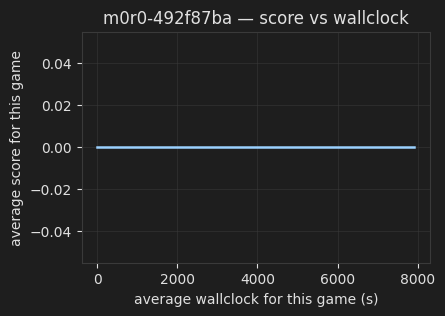
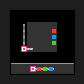
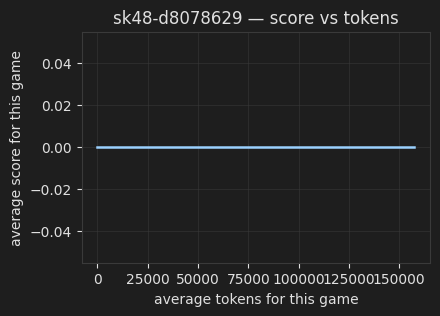
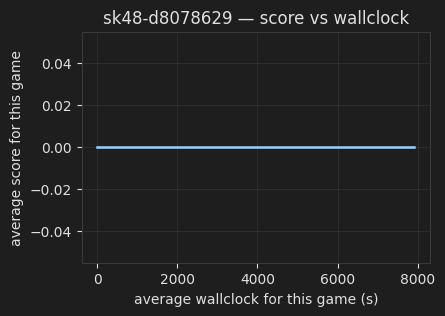
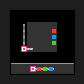
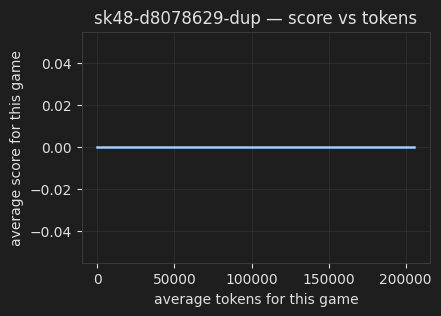
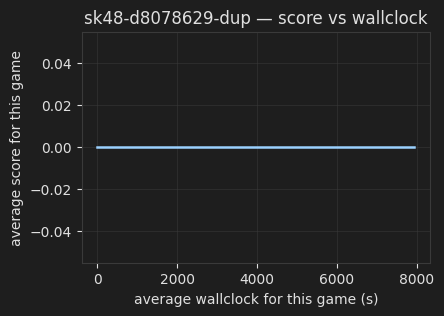
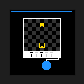
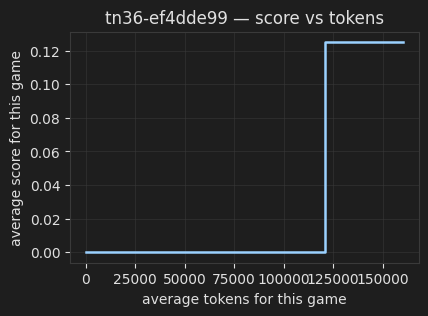
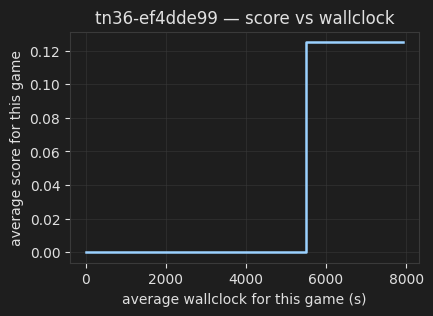
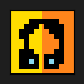
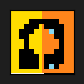
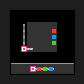
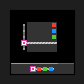
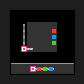
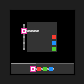
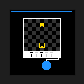
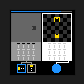

In [8]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")